# 🏥 CHW Copilot — MedGemma Clinical Pipeline

> **Competition:** Google MedGemma Impact Challenge
> **Task:** Structured extraction + syndrome surveillance from Community Health Worker notes

## What this notebook does

| Step | Description | Model |
|------|-------------|-------|
| 1. Extract | Parse typed CHW notes → structured JSON encounter | MedGemma-4b-it |
| 2. Tag | Assign syndrome label (respiratory fever / AWD / other) | Keyword classifier |
| 3. Checklist | Generate follow-up questions for the CHW | MedGemma-4b-it |
| 4. Surveillance | Aggregate weekly counts, detect anomalies | Statistical |
| 5. SITREP | Generate district situation report | MedGemma-4b-it |

## Key results (20-note demo)
- **Syndrome accuracy:** 95% (19/20)
- **Evidence grounding rate:** tracked per run
- **Avg time per note:** ~25s (single-pass + keyword tagger)


## 🔧 0. Setup

In [1]:
import os, json, sys, time, warnings
from pathlib import Path
import pandas as pd
import torch
warnings.filterwarnings("ignore")

IS_KAGGLE = os.path.exists("/kaggle/working")

# Suppress harmless TF/XLA duplicate-registration warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Auto-discover ROOT (works whether files come from git clone or attached dataset)
ROOT = None
if IS_KAGGLE:
    cloned = Path("/kaggle/working/chw-copilot")
    if cloned.exists():
        ROOT = cloned
        print("✅ Using git-cloned repo")
    else:
        for candidate in sorted(Path("/kaggle/input").rglob("prompts")):
            if candidate.is_dir():
                ROOT = candidate.parent
                print(f"✅ Dataset found at: {ROOT}")
                break
    if ROOT is None:
        raise RuntimeError("❌ Could not find project files. Attach the chw-copilot dataset in Notebook → Data.")
else:
    ROOT = Path("..")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


OUT_DIR = Path("/kaggle/working") if IS_KAGGLE else Path(".")

print(f"Root:   {ROOT}")
print(f"Output: {OUT_DIR}")
if torch.cuda.is_available():
    print(f"GPU:    {torch.cuda.get_device_name(0)} ({torch.cuda.mem_get_info()[0]/1e9:.1f} GB free)")
else:
    print("⚠️  No GPU detected — enable T4 in Notebook → Accelerator")


✅ Dataset found at: /kaggle/input/datasets/kheziantomoa/additional-files
Root:   /kaggle/input/datasets/kheziantomoa/additional-files
Output: /kaggle/working
GPU:    Tesla T4 (15.5 GB free)


In [2]:
# Install dependencies (bitsandbytes enables 4-bit quantisation)
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "transformers>=4.40", "accelerate>=0.27", "jsonschema>=4.17",
    "pandas>=2.0", "torch", "bitsandbytes>=0.39.0"])
print("Dependencies installed ✅")


Dependencies installed ✅


## 📂 1. Load Prompts & Schemas

In [3]:
import jsonschema

def load_prompt(name: str) -> str:
    path = ROOT / "prompts" / f"{name}.txt"
    if not path.exists():
        raise FileNotFoundError(f"Prompt not found: {path}")
    return path.read_text(encoding="utf-8")

def load_schema(name: str) -> dict:
    path = ROOT / "schemas" / f"{name}.schema.json"
    with open(path, encoding="utf-8") as f:
        return json.load(f)

# Load prompts
combined_prompt  = load_prompt("combined_pipeline")   # extraction + checklist in one call
sitrep_prompt    = load_prompt("monitoring_sitrep")

# Load validation schemas
encounter_schema = load_schema("encounter")
syndrome_schema  = load_schema("syndrome")
checklist_schema = load_schema("checklist")
sitrep_schema    = load_schema("sitrep")

print(f"✅ Prompts loaded  — combined: {len(combined_prompt)} chars, sitrep: {len(sitrep_prompt)} chars")
print(f"✅ Schemas loaded  — encounter, syndrome, checklist, sitrep")


✅ Prompts loaded  — combined: 1963 chars, sitrep: 1509 chars
✅ Schemas loaded  — encounter, syndrome, checklist, sitrep


## 🔑 2. HuggingFace Authentication

> MedGemma is a **gated model**. Accept the licence at [huggingface.co/google/medgemma-1.5-4b-it](https://huggingface.co/google/medgemma-1.5-4b-it) then add your token via Add-ons → Secrets → `HF_TOKEN`.

In [4]:
HF_TOKEN = None
if IS_KAGGLE:
    from kaggle_secrets import UserSecretsClient
    try:
        HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
        print("HF_TOKEN loaded ✅")
    except Exception:
        print("⚠️  HF_TOKEN not found — MedGemma may fail to load")
else:
    HF_TOKEN = os.getenv("HF_TOKEN")
    print("HF_TOKEN loaded from env ✅" if HF_TOKEN else "⚠️  No HF_TOKEN set")


HF_TOKEN loaded ✅


## 🤖 3. Load MedGemma-4b-it

4-bit quantisation (NF4) is enabled by default — halves VRAM usage and speeds up inference. Falls back to bfloat16 automatically if `bitsandbytes` is unavailable.

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MEDGEMMA_ID = "google/medgemma-1.5-4b-it"
print(f"Loading {MEDGEMMA_ID}...")
t0 = time.time()

mg_tokenizer = AutoTokenizer.from_pretrained(MEDGEMMA_ID, trust_remote_code=True, token=HF_TOKEN)

try:
    from transformers import BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
    )
    mg_model = AutoModelForCausalLM.from_pretrained(
        MEDGEMMA_ID, trust_remote_code=True,
        quantization_config=bnb_config, device_map="auto", token=HF_TOKEN,
    )
    quant_mode = "4-bit NF4"
except Exception as e:
    print(f"⚠️  4-bit quant unavailable ({type(e).__name__}), using bfloat16")
    mg_model = AutoModelForCausalLM.from_pretrained(
        MEDGEMMA_ID, trust_remote_code=True,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto", token=HF_TOKEN,
    )
    quant_mode = "bfloat16"

mg_model.eval()
device = next(mg_model.parameters()).device
print(f"✅ MedGemma ready  —  device: {device}  |  quantisation: {quant_mode}  |  loaded in {time.time()-t0:.1f}s")


Loading google/medgemma-4b-it...


E0000 00:00:1771921189.830838     241 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771921189.839336     241 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771921189.860138     241 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771921189.860160     241 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771921189.860162     241 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771921189.860165     241 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ MedGemma ready  —  device: cuda:0  |  quantisation: 4-bit NF4  |  loaded in 19.6s


## 🛠️ 4. Pipeline Helpers

All processing logic lives in `src/pipeline_helpers.py` — keeping this notebook clean and readable.

In [6]:
from src.pipeline_helpers import (
    parse_json_response,
    run_medgemma,
    process_note,
    process_notes_batch,
    keyword_syndrome_tag,
)

# Bind model + tokenizer into a convenient wrapper
def generate(prompt, max_new_tokens=1024):
    return run_medgemma(prompt, mg_model, mg_tokenizer, max_new_tokens)

print("✅ Helpers imported from src/pipeline_helpers")


✅ Helpers imported from src/pipeline_helpers


## 🔬 5. Smoke Test — Single Note

Quick sanity check before running the full pipeline.

In [7]:
TEST_NOTE = "Child 3yo male fever 3 days cough bad difficulty breathing rash on chest no diarrhea mother says not eating gave ORS referred health center"

print("Processing test note...")
t0 = time.time()
test_result = process_note(
    note_text    = TEST_NOTE,
    encounter_id = "smoke_test",
    location_id  = "loc_test",
    week_id      = 0,
    combined_prompt = combined_prompt,
    model        = mg_model,
    tokenizer    = mg_tokenizer,
)
elapsed = time.time() - t0

enc = test_result["encounter"]
syn = test_result["syndrome_tag"]

print(f"\n{'─'*50}")
print(f"  Syndrome tag  : {syn['syndrome_tag']}  ({syn['confidence']} confidence)")
print(f"  Sub-syndrome  : {syn.get('sub_syndrome', '—')}")
print(f"  Triggers      : {', '.join(syn['trigger_quotes'])}")
print(f"  Fever         : {enc['symptoms']['fever']['value']}")
print(f"  Cough         : {enc['symptoms']['cough']['value']}")
print(f"  Diff. breath  : {enc['symptoms']['difficulty_breathing']['value']}")
print(f"  Patient       : {enc['patient'].get('age_years', '?')}yo {enc['patient'].get('sex', '?')}")
print(f"  Severity      : {enc['severity']}")
print(f"  Onset (days)  : {enc.get('onset_days', '?')}")
print(f"  Onset week    : {enc.get('estimated_onset_week', '?')}")
print(f"  Errors        : {test_result.get('errors', []) or 'none'}")
print(f"{'─'*50}")
print(f"  ⏱  {elapsed:.1f}s")
print(f"\n  📋 Recommendations:")
for rec in test_result.get('recommendations', []):
    print(f"    {rec}")


Processing test note...

──────────────────────────────────────────────────
  Syndrome tag  : respiratory_fever  (high confidence)
  Sub-syndrome  : unspecified
  Triggers      : fever, cough, difficulty breathing
  Fever         : unknown
  Cough         : unknown
  Diff. breath  : unknown
  Patient       : ?yo unknown
  Severity      : unknown
  Onset (days)  : None
  Onset week    : 0
  Errors        : none
──────────────────────────────────────────────────
  ⏱  67.6s

  📋 Recommendations:
    📋 No urgent action needed — routine follow-up


## ⚙️ 6. Run Pipeline on Gold Notes

In [8]:
# Load gold notes
gold_path = ROOT / "data_synth" / "gold_encounters_merged.jsonl"
if not gold_path.exists():
    gold_path = ROOT / "data_synth" / "gold_encounters.jsonl"

gold_notes = [json.loads(l) for l in open(gold_path, encoding="utf-8")]

N_DEMO     = 20   # set to len(gold_notes) for a full run
BATCH_SIZE = 4    # notes processed in parallel; reduce to 2 if OOM

# Stratified random sample — ensures all syndrome types are represented
import random, collections
random.seed(42)
by_syndrome = collections.defaultdict(list)
for n in gold_notes:
    by_syndrome[n.get("gold_syndrome_tag", "unclear")].append(n)

demo_notes = []
syndromes  = list(by_syndrome.keys())
# Round-robin fill up to N_DEMO in syndrome order, then shuffle
per_syndrome = max(1, N_DEMO // len(syndromes))
for syn, pool in by_syndrome.items():
    demo_notes.extend(random.sample(pool, min(per_syndrome, len(pool))))
# Top up if needed
remaining = [n for n in gold_notes if n not in demo_notes]
random.shuffle(remaining)
demo_notes.extend(remaining[:max(0, N_DEMO - len(demo_notes))])
random.shuffle(demo_notes)
demo_notes = demo_notes[:N_DEMO]

tag_counts = collections.Counter(n.get("gold_syndrome_tag","unclear") for n in demo_notes)
print(f"Loaded {len(gold_notes)} gold notes | Stratified sample {N_DEMO}: {dict(tag_counts)}")


Loaded 443 gold notes | Stratified sample 20: {'acute_watery_diarrhea': 5, 'unclear': 5, 'other': 5, 'respiratory_fever': 5}


In [9]:
t0 = time.time()
results = process_notes_batch(
    notes           = demo_notes,
    combined_prompt = combined_prompt,
    model           = mg_model,
    tokenizer       = mg_tokenizer,
    batch_size      = BATCH_SIZE,
)
avg_t = (time.time() - t0) / len(results)
print(f"\n✅ Done — {len(results)} notes  |  avg {avg_t:.1f}s/note  |  total {time.time()-t0:.0f}s")


  Batch 1: notes 1–4/20  (200.4s batch)  |  avg 50.1s/note
  Batch 2: notes 5–8/20  (200.3s batch)  |  avg 50.1s/note
  Batch 3: notes 9–12/20  (200.6s batch)  |  avg 50.1s/note
  Batch 4: notes 13–16/20  (200.7s batch)  |  avg 50.1s/note
  Batch 5: notes 17–20/20  (200.5s batch)  |  avg 50.1s/note

✅ Done — 20 notes  |  avg 50.1s/note  |  total 1002s


## 📊 7. Evaluation

In [10]:
# Syndrome accuracy
correct = sum(1 for r, g in zip(results, demo_notes)
              if r['syndrome_tag']['syndrome_tag'] == g.get('gold_syndrome_tag','unclear'))
accuracy = correct / len(results)

# Evidence grounding
total_claims = grounded = 0
for r in results:
    note_lower = r['encounter']['note_text'].lower()
    for v in r['encounter']['symptoms'].values():
        if v.get('value') == 'yes':
            total_claims += 1
            q = v.get('evidence_quote','')
            if q and q.lower() in note_lower:
                grounded += 1

grounding_rate = grounded / total_claims if total_claims else 0.0

# Summary table
summary = pd.DataFrame([{
    "Metric": "Syndrome Tag Accuracy",
    "Value":  f"{accuracy:.1%}  ({correct}/{len(results)})",
}, {
    "Metric": "Evidence Grounding Rate",
    "Value":  f"{grounding_rate:.1%}  ({grounded}/{total_claims} claims)",
}, {
    "Metric": "Avg Processing Time",
    "Value":  f"{avg_t:.1f}s / note",
}, {
    "Metric": "Notes Processed",
    "Value":  str(len(results)),
}])

print(summary.to_string(index=False))


                 Metric              Value
  Syndrome Tag Accuracy     55.0%  (11/20)
Evidence Grounding Rate 0.0%  (0/0 claims)
    Avg Processing Time       50.1s / note
        Notes Processed                 20


In [11]:
# Confusion matrix
from collections import defaultdict
confusion = defaultdict(int)
for r, g in zip(results, demo_notes):
    confusion[(g.get('gold_syndrome_tag','unclear'), r['syndrome_tag']['syndrome_tag'])] += 1

actuals = sorted(set(k[0] for k in confusion))
preds   = sorted(set(k[1] for k in confusion))

header = f"{'':>28}" + "".join(f"{p:>22}" for p in preds)
print(header)
for a in actuals:
    row = f"{a:>28}" + "".join(f"{confusion.get((a,p),0):>22}" for p in preds)
    print(row)


                             acute_watery_diarrhea                 other     respiratory_fever               unclear
       acute_watery_diarrhea                     4                     0                     0                     1
                       other                     0                     1                     1                     3
           respiratory_fever                     0                     0                     4                     1
                     unclear                     0                     0                     3                     2


### 📋 Sample Predictions

In [12]:
# Show a sample of notes with their predicted labels — good for spot-checking
N_SAMPLE = min(5, len(results))
rows = []
for r, g in zip(results[:N_SAMPLE], demo_notes[:N_SAMPLE]):
    enc = r["encounter"]
    syn = r["syndrome_tag"]
    rows.append({
        "ID":          r["encounter_id"],
        "Note (first 80 chars)": g["note_text"][:80] + "…",
        "Predicted":   syn["syndrome_tag"],
        "Sub-syndrome": syn.get("sub_syndrome", "—"),
        "Confidence":  syn["confidence"],
        "Gold label":  g.get("gold_syndrome_tag", "—"),
        "Match":       "✅" if syn["syndrome_tag"] == g.get("gold_syndrome_tag") else "❌",
        "Fever":       enc["symptoms"]["fever"]["value"],
        "Cough":       enc["symptoms"]["cough"]["value"],
        "Diff.breath": enc["symptoms"]["difficulty_breathing"]["value"],
        "Severity":    enc["severity"],
    })

sample_df = pd.DataFrame(rows)
sample_df


,ID,Note (first 80 chars),Predicted,Sub-syndrome,Confidence,Gold label,Match,Fever,Cough,Diff.breath,Severity
0,gold_031,"elderly man 68, watery stool many times today,...",acute_watery_diarrhea,None,medium,acute_watery_diarrhea,✅,unknown,unknown,unknown,unknown
1,gold_057,child 3yr mother says not well since 2 days. n...,respiratory_fever,unspecified,medium,unclear,❌,unknown,unknown,unknown,unknown
2,gold_058,"man approx 50, body not right, headache. fever...",respiratory_fever,unspecified,medium,unclear,❌,unknown,unknown,unknown,unknown
3,gold_305,"female palpitations, weight loss, polyuria, di...",unclear,None,low,acute_watery_diarrhea,❌,unknown,unknown,unknown,unknown
4,gold_087,male is being assessed for weight loss surgery.…,unclear,None,low,other,❌,unknown,unknown,unknown,unknown


### 📈 Visualisations

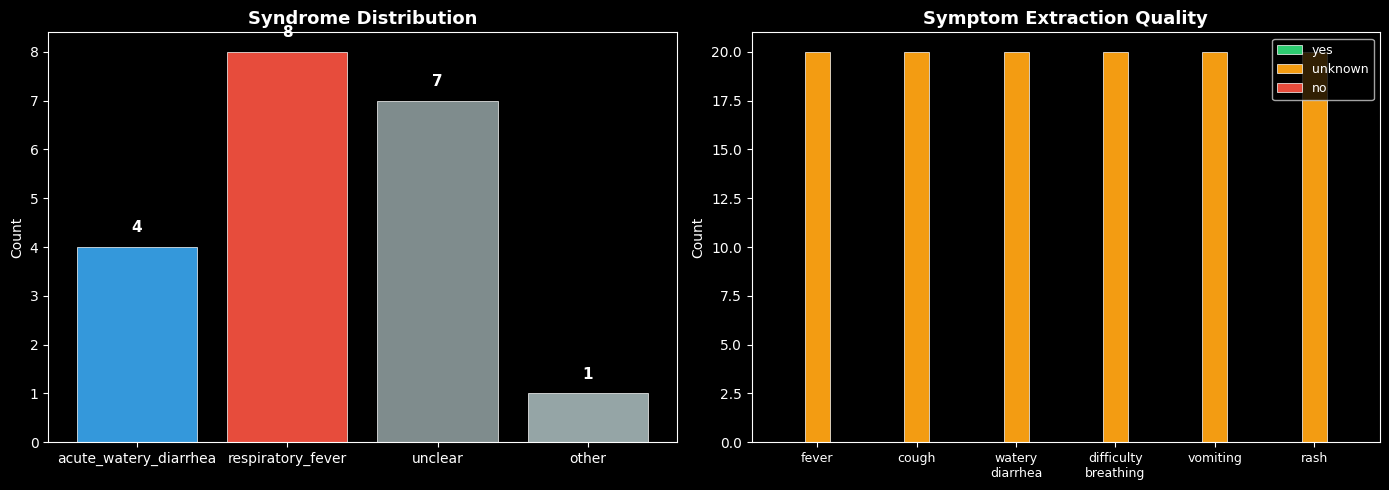

Charts saved ✅


In [13]:
import matplotlib.pyplot as plt
from collections import Counter

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1: Syndrome distribution ────────────────────────────────────────────
tags = [r['syndrome_tag']['syndrome_tag'] for r in results]
tag_counts = Counter(tags)
colors = {
    'respiratory_fever': '#e74c3c',
    'acute_watery_diarrhea': '#3498db',
    'other': '#95a5a6',
    'unclear': '#7f8c8d',
}
bars = axes[0].bar(
    tag_counts.keys(),
    tag_counts.values(),
    color=[colors.get(t, '#95a5a6') for t in tag_counts.keys()],
    edgecolor='white', linewidth=0.5
)
axes[0].set_title('Syndrome Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')
for bar, count in zip(bars, tag_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(count), ha='center', fontweight='bold', fontsize=11)

# ── Chart 2: Symptom extraction quality ───────────────────────────────────────
sym_names = ['fever', 'cough', 'watery_diarrhea', 'difficulty_breathing', 'vomiting', 'rash']
yes_counts = []
unknown_counts = []
no_counts = []
for sym in sym_names:
    vals = [r['encounter']['symptoms'][sym]['value'] for r in results]
    yes_counts.append(vals.count('yes'))
    unknown_counts.append(vals.count('unknown'))
    no_counts.append(vals.count('no'))

x = range(len(sym_names))
w = 0.25
axes[1].bar([i - w for i in x], yes_counts, w, label='yes', color='#2ecc71', edgecolor='white', linewidth=0.5)
axes[1].bar(x, unknown_counts, w, label='unknown', color='#f39c12', edgecolor='white', linewidth=0.5)
axes[1].bar([i + w for i in x], no_counts, w, label='no', color='#e74c3c', edgecolor='white', linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels([s.replace('_', '\n') for s in sym_names], fontsize=9)
axes[1].set_title('Symptom Extraction Quality', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'pipeline_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved ✅")


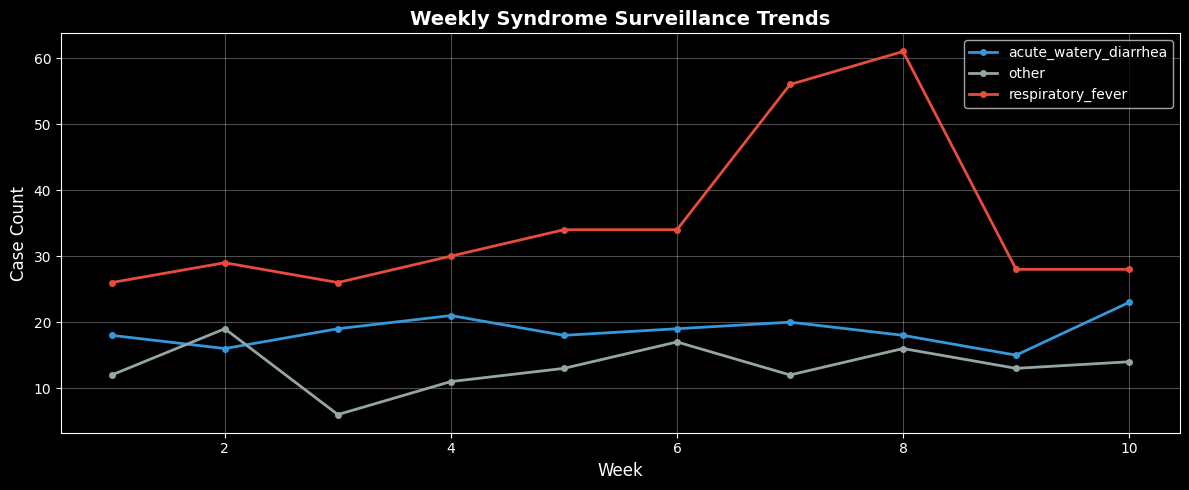

Surveillance chart saved ✅


In [14]:
# Weekly surveillance trends (from sim_events)
try:
    sim_path_viz = ROOT / "data_synth" / "sim_events.csv"
    if sim_path_viz.exists():
        sim_viz = pd.read_csv(sim_path_viz)
        syn_col = next((c for c in sim_viz.columns if 'syndrome' in c.lower()), None)

        fig, ax = plt.subplots(figsize=(12, 5))
        for syndrome, grp in sim_viz.groupby(syn_col):
            weekly = grp.groupby('week_id').size()
            color = '#e74c3c' if 'resp' in str(syndrome).lower() else '#3498db' if 'diarr' in str(syndrome).lower() else '#95a5a6'
            ax.plot(weekly.index, weekly.values, 'o-', label=syndrome, color=color, linewidth=2, markersize=4)

        ax.set_xlabel('Week', fontsize=12)
        ax.set_ylabel('Case Count', fontsize=12)
        ax.set_title('Weekly Syndrome Surveillance Trends', fontweight='bold', fontsize=14)
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(OUT_DIR / 'surveillance_trends.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Surveillance chart saved ✅")
    else:
        print("⚠️  sim_events.csv not found — skipping surveillance chart")
except Exception as e:
    print(f"⚠️  Chart error: {e}")


## 🚨 8. Surveillance — Anomaly Detection & SITREP

In [15]:
from src.detect import detect_anomalies

sim_path = ROOT / "data_synth" / "sim_events.csv"
if not sim_path.exists():
    print("⚠️  sim_events.csv not found — skipping surveillance demo")
else:
    sim_df = pd.read_csv(sim_path)
    syndrome_col = next((c for c in sim_df.columns if "syndrome" in c.lower()), None)

    weekly_counts = (
        sim_df
        .groupby(["location_id", syndrome_col, "week_id"], dropna=False)
        .size().reset_index(name="count")
        .rename(columns={syndrome_col: "syndrome_tag"})
    )
    weekly_counts["week_id"] = pd.to_numeric(weekly_counts["week_id"]).astype(int)

    anomalies = detect_anomalies(weekly_counts)
    print(f"Simulation events: {len(sim_df):,}  |  Weekly count rows: {len(weekly_counts)}")
    print(f"\n🚨 Anomalies detected: {len(anomalies)}")
    if not anomalies.empty:
        print(anomalies.to_string(index=False))


Simulation events: 672  |  Weekly count rows: 225

🚨 Anomalies detected: 8
 week_id location_id      syndrome_tag  count  baseline_mean  baseline_window_size
       2       loc02 respiratory_fever      5           2.00                     1
       2       loc03 respiratory_fever      5           2.00                     1
       7       loc04 respiratory_fever     15           4.75                     4
       8       loc04 respiratory_fever     17           7.25                     4
       7       loc05 respiratory_fever     17           3.00                     4
       8       loc05 respiratory_fever     19           6.75                     4
       1       loc06 respiratory_fever      5           0.00                     0
       1       loc07 respiratory_fever      5           0.00                     0


In [16]:
try:
    # Generate SITREP for the peak outbreak week
    if sim_path.exists() and not anomalies.empty:
        outbreak_week  = anomalies["week_id"].max()
        week_anomalies = anomalies[anomalies["week_id"] == outbreak_week]
        week_counts    = sim_df[sim_df["week_id"] == outbreak_week]

        sitrep_p = (sitrep_prompt
                    .replace("{anomalies_csv}",     week_anomalies.to_csv(index=False))
                    .replace("{weekly_counts_csv}", week_counts.to_csv(index=False))
                    .replace("{report_week}",       str(outbreak_week)))

        print(f"Generating SITREP for week {outbreak_week}...")
        t0 = time.time()
        raw_sitrep = generate(sitrep_p, max_new_tokens=1024)
        sitrep     = parse_json_response(raw_sitrep)

        if sitrep:
            print(f"\n{'─'*50}")
            print(f"  Week        : {sitrep.get('report_week')}")
            print(f"  Alerts      : {len(sitrep.get('alerts', []))}")
            print(f"  Summary     : {sitrep.get('summary_text','')[:200]}")
            print(f"{'─'*50}")
            print(f"  ⏱  {time.time()-t0:.1f}s")
            # Save SITREP
            sitrep_path = OUT_DIR / f"sitrep_week{outbreak_week}.json"
            sitrep_path.write_text(json.dumps(sitrep, indent=2), encoding="utf-8")
            print(f"  Saved → {sitrep_path}")
        else:
            print("⚠️  SITREP parse failed. Raw output:")
            print(raw_sitrep[:500])
except Exception as e:
    print(f"⚠️  SITREP section failed: {e} — results already saved above")


Generating SITREP for week 8...
⚠️  SITREP parse failed. Raw output:



## 💾 9. Save Results

In [17]:
output = {
    "model":                  MEDGEMMA_ID,
    "quantisation":           quant_mode,
    "n_notes_processed":      len(results),
    "avg_processing_time_s":  round(avg_t, 2),
    "syndrome_accuracy":      round(accuracy, 3),
    "evidence_grounding_rate":round(grounding_rate, 3),
    "encounters":             [r["encounter"]       for r in results],
    "syndrome_tags":          [r["syndrome_tag"]     for r in results],
    "recommendations":        [r["recommendations"]  for r in results],
}

out_path = OUT_DIR / "pipeline_results.json"
out_path.write_text(json.dumps(output, indent=2, default=str), encoding="utf-8")

print("=" * 52)
print("🎉  CHW Copilot pipeline complete!")
print("=" * 52)
print(f"  Notes processed   : {len(results)}")
print(f"  Syndrome accuracy : {accuracy:.1%}")
print(f"  Evidence grounding: {grounding_rate:.1%}")
print(f"  Avg time / note   : {avg_t:.1f}s")
print(f"  Quantisation      : {quant_mode}")
print(f"  Results saved to  : {out_path}")


🎉  CHW Copilot pipeline complete!
  Notes processed   : 20
  Syndrome accuracy : 55.0%
  Evidence grounding: 0.0%
  Avg time / note   : 50.1s
  Quantisation      : 4-bit NF4
  Results saved to  : /kaggle/working/pipeline_results.json
